In [1]:
import pandas as pd
import sqlite3
import os
import matplotlib.pyplot as plt

# 현재 작업 경로 확인
print("현재 작업 폴더:", os.getcwd())

# DB 연결
conn = sqlite3.connect("../db/olist.db")

# 배송 관련 기본 범위 확인
print(pd.read_sql("""
SELECT
    COUNT(*) AS total_orders,
    SUM(CASE WHEN order_status = 'delivered' THEN 1 ELSE 0 END) AS delivered_orders,
    SUM(CASE WHEN order_delivered_customer_date IS NULL THEN 1 ELSE 0 END) AS null_delivered_date,
    SUM(CASE WHEN order_estimated_delivery_date IS NULL THEN 1 ELSE 0 END) AS null_estimated_date
FROM orders;
""", conn))

현재 작업 폴더: /Users/chaeyoung/Documents/GitHub/olist-ecommerce-analysis/notebooks
   total_orders  delivered_orders  null_delivered_date  null_estimated_date
0         99441             96478                 2965                    0


In [2]:
# delivered 주문 기준 배송 소요일, 예상일 대비 지연 여부 분석
delivery_summary = pd.read_sql("""
WITH delivered_orders AS (
    SELECT
        order_id,
        order_purchase_timestamp,
        order_delivered_customer_date,
        order_estimated_delivery_date,
        julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp) AS delivery_days,
        julianday(order_delivered_customer_date) - julianday(order_estimated_delivery_date) AS delay_days
    FROM orders
    WHERE order_status = 'delivered'
      AND order_purchase_timestamp IS NOT NULL
      AND order_delivered_customer_date IS NOT NULL
      AND order_estimated_delivery_date IS NOT NULL
)
SELECT
    COUNT(*) AS delivered_orders,
    ROUND(AVG(delivery_days), 2) AS avg_delivery_days,
    ROUND(MIN(delivery_days), 2) AS min_delivery_days,
    ROUND(MAX(delivery_days), 2) AS max_delivery_days,
    ROUND(AVG(delay_days), 2) AS avg_delay_days,
    SUM(CASE WHEN delay_days > 0 THEN 1 ELSE 0 END) AS delayed_orders,
    ROUND(SUM(CASE WHEN delay_days > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS delayed_order_pct
FROM delivered_orders;
""", conn)

print(delivery_summary)

   delivered_orders  avg_delivery_days  min_delivery_days  max_delivery_days  \
0             96470              12.56               0.53             209.63   

   avg_delay_days  delayed_orders  delayed_order_pct  
0          -11.18            7826               8.11  


  order_month  delivered_orders  avg_delivery_days  avg_delay_days  \
0     2016-09                 1              54.81           36.32   
1     2016-10               265              19.60          -36.08   
2     2016-12                 1               4.69          -21.34   
3     2017-01               750              12.65          -26.86   
4     2017-02              1653              13.17          -18.68   

   delayed_order_pct  
0             100.00  
1               1.13  
2               0.00  
3               3.07  
4               3.21  


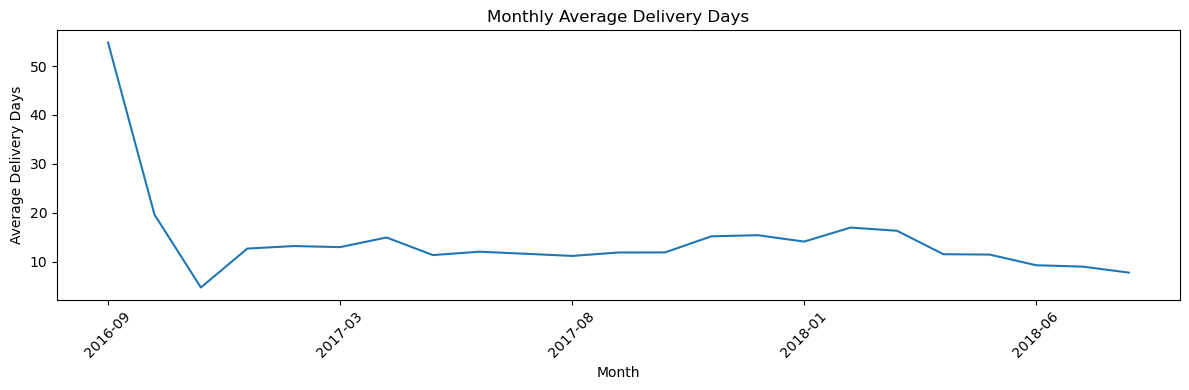

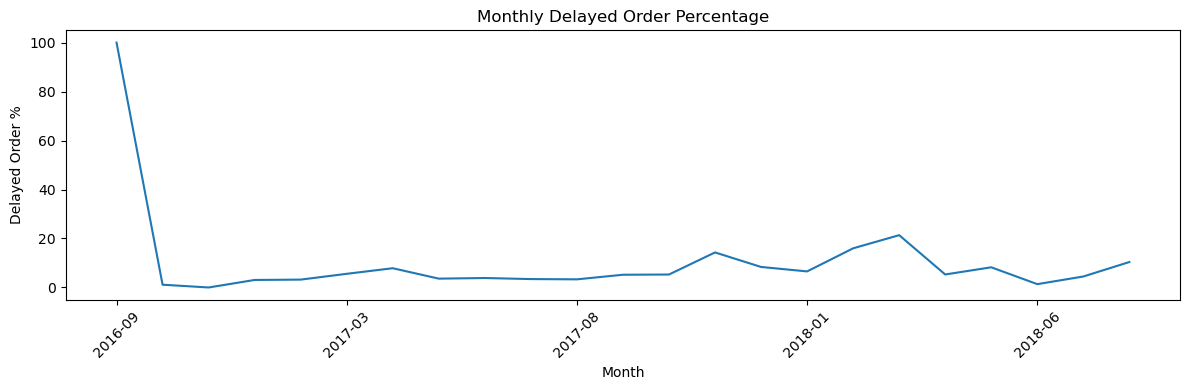

In [3]:
# 월별 배송 성과 추이
monthly_delivery = pd.read_sql("""
WITH delivered_orders AS (
    SELECT
        strftime('%Y-%m', order_purchase_timestamp) AS order_month,
        julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp) AS delivery_days,
        julianday(order_delivered_customer_date) - julianday(order_estimated_delivery_date) AS delay_days
    FROM orders
    WHERE order_status = 'delivered'
      AND order_purchase_timestamp IS NOT NULL
      AND order_delivered_customer_date IS NOT NULL
      AND order_estimated_delivery_date IS NOT NULL
)
SELECT
    order_month,
    COUNT(*) AS delivered_orders,
    ROUND(AVG(delivery_days), 2) AS avg_delivery_days,
    ROUND(AVG(delay_days), 2) AS avg_delay_days,
    ROUND(SUM(CASE WHEN delay_days > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS delayed_order_pct
FROM delivered_orders
GROUP BY order_month
ORDER BY order_month;
""", conn)

print(monthly_delivery.head())

# 월별 평균 배송일
monthly_delivery.plot(
    x="order_month",
    y="avg_delivery_days",
    figsize=(12, 4),
    legend=False
)

plt.title("Monthly Average Delivery Days")
plt.xlabel("Month")
plt.ylabel("Average Delivery Days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 월별 지연 주문 비율
monthly_delivery.plot(
    x="order_month",
    y="delayed_order_pct",
    figsize=(12, 4),
    legend=False
)

plt.title("Monthly Delayed Order Percentage")
plt.xlabel("Month")
plt.ylabel("Delayed Order %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

   customer_state  delivered_orders  avg_delivery_days  avg_delay_days  \
0              AM               145              26.43          -18.85   
1              AL               397              24.54           -8.03   
2              PA               946              23.77          -13.39   
3              MA               717              21.57           -8.89   
4              SE               335              21.52           -9.33   
5              CE              1279              21.27          -10.11   
6              PB               517              20.43          -12.60   
7              PI               476              19.46          -10.63   
8              RO               243              19.37          -19.40   
9              BA              3256              19.34          -10.10   
10             RN               474              19.28          -12.96   
11             PE              1593              18.45          -12.61   
12             MT               886   

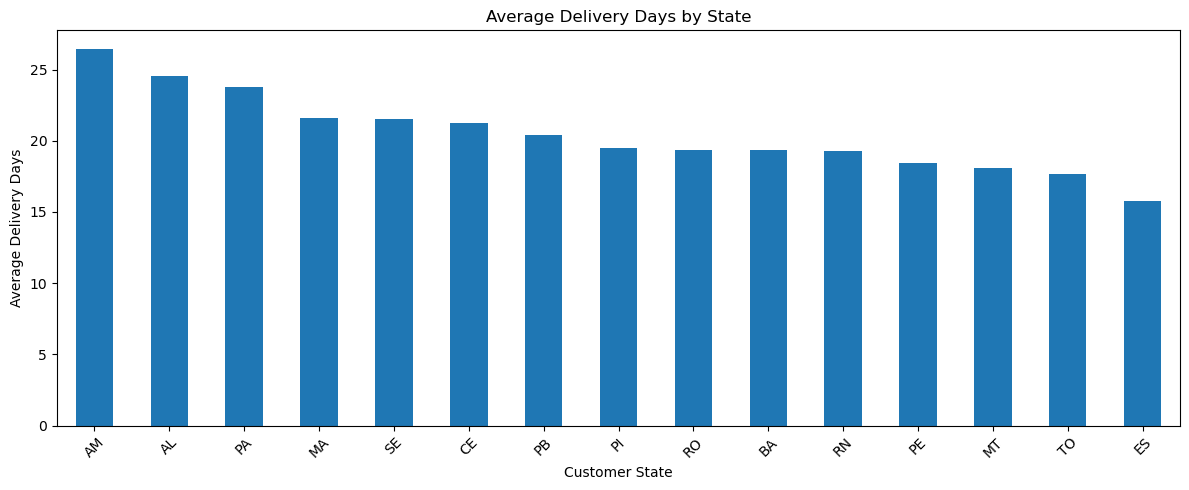

In [4]:
# 고객 주(state) 기준 평균 배송일 분석
state_delivery = pd.read_sql("""
WITH delivered_orders AS (
    SELECT
        c.customer_state,
        julianday(o.order_delivered_customer_date) - julianday(o.order_purchase_timestamp) AS delivery_days,
        julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date) AS delay_days
    FROM orders o
    JOIN customers c
        ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
      AND o.order_purchase_timestamp IS NOT NULL
      AND o.order_delivered_customer_date IS NOT NULL
      AND o.order_estimated_delivery_date IS NOT NULL
)
SELECT
    customer_state,
    COUNT(*) AS delivered_orders,
    ROUND(AVG(delivery_days), 2) AS avg_delivery_days,
    ROUND(AVG(delay_days), 2) AS avg_delay_days,
    ROUND(SUM(CASE WHEN delay_days > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS delayed_order_pct
FROM delivered_orders
GROUP BY customer_state
HAVING COUNT(*) >= 100
ORDER BY avg_delivery_days DESC
LIMIT 15;
""", conn)

print(state_delivery)

# 지역별 평균 배송일 시각화
state_delivery.plot(
    kind="bar",
    x="customer_state",
    y="avg_delivery_days",
    figsize=(12, 5),
    legend=False
)

plt.title("Average Delivery Days by State")
plt.xlabel("Customer State")
plt.ylabel("Average Delivery Days")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()